In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('concrete_data.csv')
df.columns = df.columns.str.strip()
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [5]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [7]:
print(df.isnull().sum())

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64


In [8]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 25


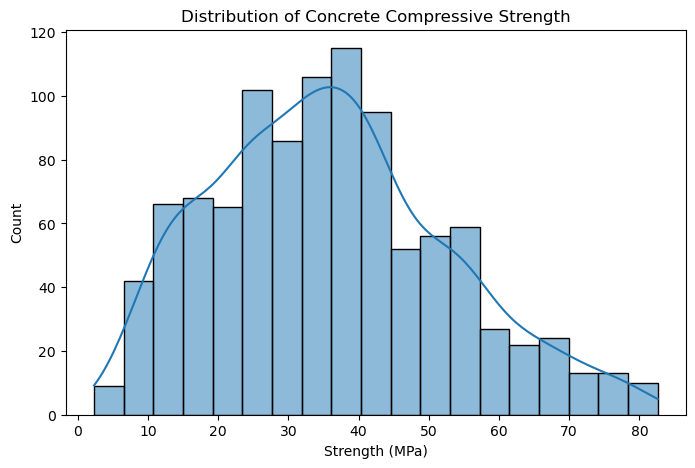

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['concrete_compressive_strength'], kde=True)
plt.title('Distribution of Concrete Compressive Strength')
plt.xlabel('Strength (MPa)')
plt.show()

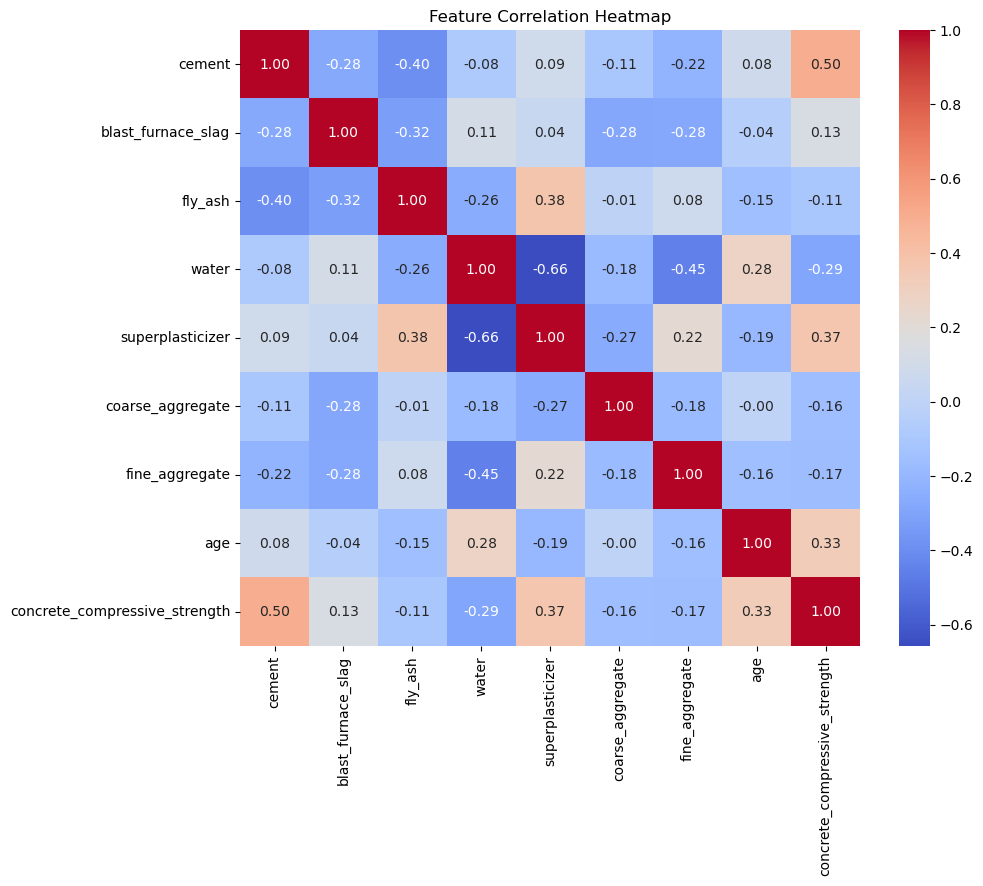

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (1005, 9)


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('concrete_compressive_strength', axis=1)
y = df['concrete_compressive_strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (804, 8), Test: (201, 8)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'SVR': SVR(kernel='rbf'),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=200)
}

results = {}

for name, model in models.items():
    if name in ['Linear Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}

results_df = pd.DataFrame(results).T
print(results_df.sort_values('R2', ascending=False))

ModuleNotFoundError: No module named 'xgboost'

In [15]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 7.5 MB/s  0:00:00 eta 0:00:0100:01


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'SVR': SVR(kernel='rbf'),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=200)
}

results = {}

for name, model in models.items():
    if name in ['Linear Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}

results_df = pd.DataFrame(results).T
print(results_df.sort_values('R2', ascending=False))

                         R2       RMSE       MAE
XGBoost            0.924887   4.733703  2.882983
Random Forest      0.909537   5.194932  3.526481
SVR                0.600069  10.922887  8.344309
Linear Regression  0.580170  11.191320  8.895256


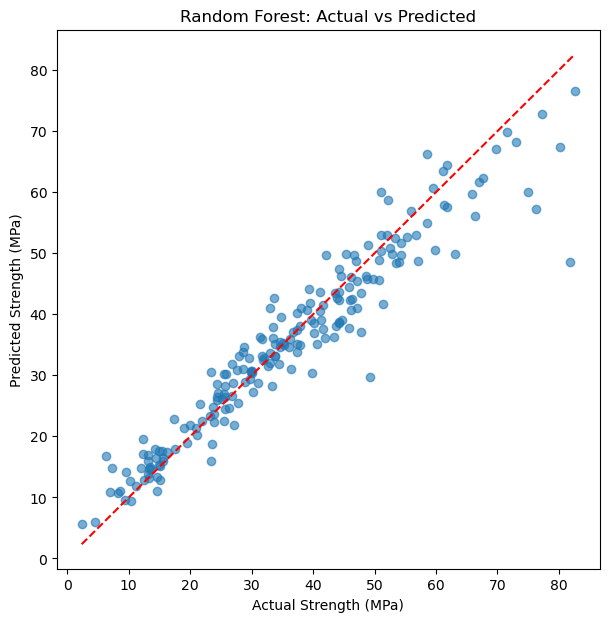

In [17]:
best_model = RandomForestRegressor(random_state=42, n_estimators=200)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

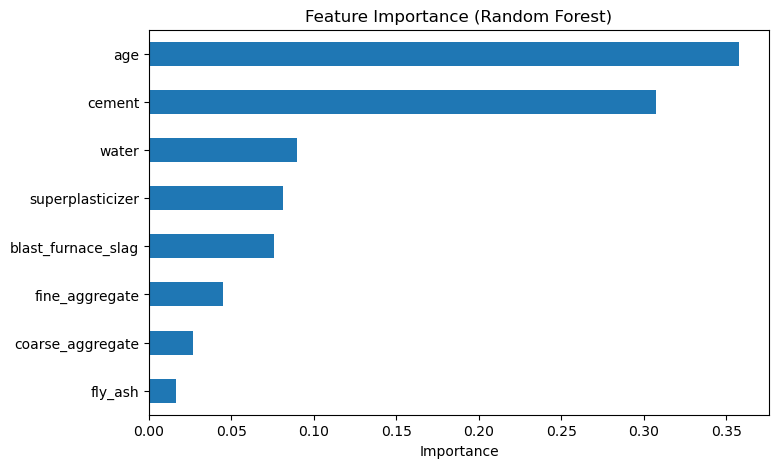

In [18]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

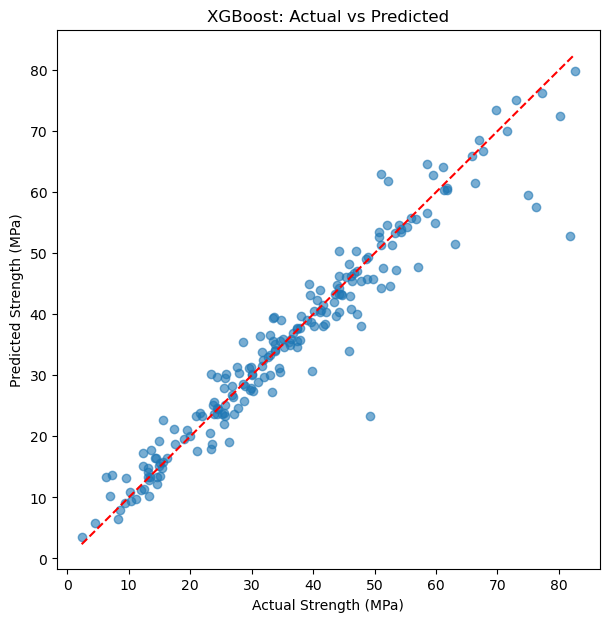

In [19]:
best_model = XGBRegressor(random_state=42, n_estimators=200)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('XGBoost: Actual vs Predicted')
plt.show()

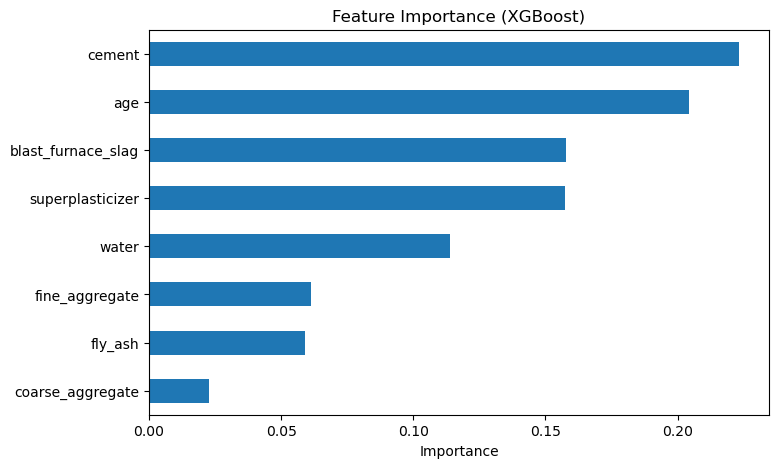

In [20]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    XGBRegressor(random_state=42, n_estimators=200),
    X, y, cv=5, scoring='r2'
)

print(f"Cross-Validation R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

Cross-Validation R² scores: [ 0.74024056  0.71985287  0.7121656   0.85232883 -0.59517113]
Mean R²: 0.4859
Std Dev: 0.5429


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV R² Score: 0.9178


In [23]:
best_xgb = grid_search.best_estimator_
tuned_preds = best_xgb.predict(X_test)

r2_tuned = r2_score(y_test, tuned_preds)
rmse_tuned = np.sqrt(mean_squared_error(y_test, tuned_preds))
mae_tuned = mean_absolute_error(y_test, tuned_preds)

print(f"Tuned XGBoost — R²: {r2_tuned:.4f}, RMSE: {rmse_tuned:.4f}, MAE: {mae_tuned:.4f}")

Tuned XGBoost — R²: 0.9375, RMSE: 4.3184, MAE: 2.7305


In [24]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    XGBRegressor(random_state=42, n_estimators=200),
    X, y, cv=kf, scoring='r2'
)

print(f"Cross-Validation R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

Cross-Validation R² scores: [0.92488746 0.93068647 0.92917164 0.92746657 0.91404277]
Mean R²: 0.9253
Std Dev: 0.0059


In [26]:
comparison = pd.DataFrame({
    'Untuned XGBoost': {'R2': 0.924887, 'RMSE': 4.733703, 'MAE': 2.882983},
    'Tuned XGBoost': {'R2': r2_tuned, 'RMSE': rmse_tuned, 'MAE': mae_tuned},
    'Cross-Val (5-fold)': {'R2': cv_scores.mean(), 'RMSE': None, 'MAE': None}
}).T
print(comparison)

                          R2      RMSE       MAE
Untuned XGBoost     0.924887  4.733703  2.882983
Tuned XGBoost       0.937490  4.318362  2.730494
Cross-Val (5-fold)  0.925251       NaN       NaN


In [27]:
import joblib
joblib.dump(best_xgb, 'concrete_strength_model.pkl')
print("Model saved as concrete_strength_model.pkl")

Model saved as concrete_strength_model.pkl


In [28]:
loaded_model = joblib.load('concrete_strength_model.pkl')

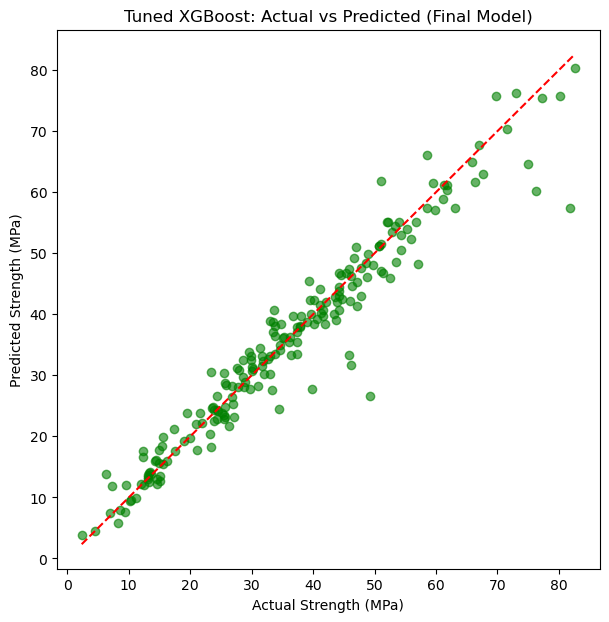

In [29]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, tuned_preds, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Tuned XGBoost: Actual vs Predicted (Final Model)')
plt.show()

In [30]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


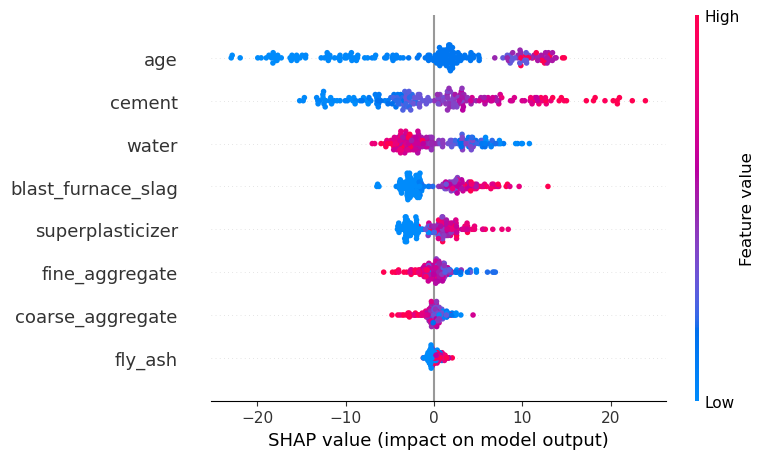

In [31]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [32]:
final_results = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR', 'Random Forest', 'XGBoost (untuned)', 'XGBoost (tuned)', 'XGBoost (5-fold CV)'],
    'R2': [0.580170, 0.600069, 0.909537, 0.924887, r2_tuned, cv_scores.mean()],
    'RMSE': [11.191320, 10.922887, 5.194932, 4.733703, rmse_tuned, None],
    'MAE': [8.895256, 8.344309, 3.526481, 2.882983, mae_tuned, None]
})

final_results.to_csv('model_results_summary.csv', index=False)
print(final_results)

                 Model        R2       RMSE       MAE
0    Linear Regression  0.580170  11.191320  8.895256
1                  SVR  0.600069  10.922887  8.344309
2        Random Forest  0.909537   5.194932  3.526481
3    XGBoost (untuned)  0.924887   4.733703  2.882983
4      XGBoost (tuned)  0.937490   4.318362  2.730494
5  XGBoost (5-fold CV)  0.925251        NaN       NaN


In [33]:
import xgboost, sklearn
print("xgboost:", xgboost.__version__)
print("scikit-learn:", sklearn.__version__)

xgboost: 3.3.0
scikit-learn: 1.7.2
